In [11]:
import os
from pathlib import Path
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [13]:
# Project Root
PROJECT_ROOT = Path("..")

# Dataset Path
DATASET_PATH = PROJECT_ROOT / "data" / "raw" / "RAVDESS"

print(DATASET_PATH)
print(DATASET_PATH.exists())

..\data\raw\RAVDESS
True


In [14]:
emotion_map = {
    "01": "Neutral",
    "02": "Calm",
    "03": "Happy",
    "04": "Sad",
    "05": "Angry",
    "06": "Fearful",
    "07": "Disgust",
    "08": "Surprised"
}

emotion_map

{'01': 'Neutral',
 '02': 'Calm',
 '03': 'Happy',
 '04': 'Sad',
 '05': 'Angry',
 '06': 'Fearful',
 '07': 'Disgust',
 '08': 'Surprised'}

In [15]:
statement_map = {
    "01": "Kids are talking by the door",
    "02": "Dogs are sitting by the door"
}

statement_map

{'01': 'Kids are talking by the door', '02': 'Dogs are sitting by the door'}

In [23]:
intensity_map = {
    "01": "Normal",
    "02": "Strong"
}

In [24]:
audio_files = []

for actor_folder in sorted(DATASET_PATH.iterdir()):

    if actor_folder.is_dir():

        for audio_file in actor_folder.glob("*.wav"):

            audio_files.append(audio_file)

print(f"Total Audio Files : {len(audio_files)}")

Total Audio Files : 1440


In [25]:
audio_files[:10]

[WindowsPath('../data/raw/RAVDESS/Actor_01/03-01-01-01-01-01-01.wav'),
 WindowsPath('../data/raw/RAVDESS/Actor_01/03-01-01-01-01-02-01.wav'),
 WindowsPath('../data/raw/RAVDESS/Actor_01/03-01-01-01-02-01-01.wav'),
 WindowsPath('../data/raw/RAVDESS/Actor_01/03-01-01-01-02-02-01.wav'),
 WindowsPath('../data/raw/RAVDESS/Actor_01/03-01-02-01-01-01-01.wav'),
 WindowsPath('../data/raw/RAVDESS/Actor_01/03-01-02-01-01-02-01.wav'),
 WindowsPath('../data/raw/RAVDESS/Actor_01/03-01-02-01-02-01-01.wav'),
 WindowsPath('../data/raw/RAVDESS/Actor_01/03-01-02-01-02-02-01.wav'),
 WindowsPath('../data/raw/RAVDESS/Actor_01/03-01-02-02-01-01-01.wav'),
 WindowsPath('../data/raw/RAVDESS/Actor_01/03-01-02-02-01-02-01.wav')]

In [26]:
sample = audio_files[0].stem

sample

'03-01-01-01-01-01-01'

In [27]:
parts = sample.split("-")

parts

['03', '01', '01', '01', '01', '01', '01']

In [28]:
print("Emotion :", emotion_map[parts[2]])
print("Intensity :", intensity_map[parts[3]])
print("Statement :", statement_map[parts[4]])
print("Actor :", int(parts[6]))

Emotion : Neutral
Intensity : Normal
Statement : Kids are talking by the door
Actor : 1


In [29]:
records = []

In [30]:
for audio_file in audio_files:

    filename = audio_file.name

    stem = audio_file.stem

    parts = stem.split("-")

    actor = int(parts[6])

    gender = "Male" if actor % 2 == 1 else "Female"

    records.append({

        "filename": filename,

        "filepath": str(audio_file),

        "emotion_code": parts[2],

        "emotion": emotion_map[parts[2]],

        "intensity": intensity_map[parts[3]],

        "statement": statement_map[parts[4]],

        "repetition": int(parts[5]),

        "actor": actor,

        "gender": gender

    })

In [31]:
metadata = pd.DataFrame(records)

metadata.head()

,filename,filepath,emotion_code,emotion,intensity,statement,repetition,actor,gender
0,03-01-01-01-01-01-01.wav,..\data\raw\RAVDESS\Actor_01\03-01-01-01-01-01...,01,Neutral,Normal,Kids are talking by the door,1,1,Male
1,03-01-01-01-01-02-01.wav,..\data\raw\RAVDESS\Actor_01\03-01-01-01-01-02...,01,Neutral,Normal,Kids are talking by the door,2,1,Male
2,03-01-01-01-02-01-01.wav,..\data\raw\RAVDESS\Actor_01\03-01-01-01-02-01...,01,Neutral,Normal,Dogs are sitting by the door,1,1,Male
3,03-01-01-01-02-02-01.wav,..\data\raw\RAVDESS\Actor_01\03-01-01-01-02-02...,01,Neutral,Normal,Dogs are sitting by the door,2,1,Male
4,03-01-02-01-01-01-01.wav,..\data\raw\RAVDESS\Actor_01\03-01-02-01-01-01...,02,Calm,Normal,Kids are talking by the door,1,1,Male


In [32]:
metadata.shape

(1440, 9)

In [33]:
metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   filename      1440 non-null   str  
 1   filepath      1440 non-null   str  
 2   emotion_code  1440 non-null   str  
 3   emotion       1440 non-null   str  
 4   intensity     1440 non-null   str  
 5   statement     1440 non-null   str  
 6   repetition    1440 non-null   int64
 7   actor         1440 non-null   int64
 8   gender        1440 non-null   str  
dtypes: int64(2), str(7)
memory usage: 101.4 KB


In [34]:
metadata.head()

,filename,filepath,emotion_code,emotion,intensity,statement,repetition,actor,gender
0,03-01-01-01-01-01-01.wav,..\data\raw\RAVDESS\Actor_01\03-01-01-01-01-01...,01,Neutral,Normal,Kids are talking by the door,1,1,Male
1,03-01-01-01-01-02-01.wav,..\data\raw\RAVDESS\Actor_01\03-01-01-01-01-02...,01,Neutral,Normal,Kids are talking by the door,2,1,Male
2,03-01-01-01-02-01-01.wav,..\data\raw\RAVDESS\Actor_01\03-01-01-01-02-01...,01,Neutral,Normal,Dogs are sitting by the door,1,1,Male
3,03-01-01-01-02-02-01.wav,..\data\raw\RAVDESS\Actor_01\03-01-01-01-02-02...,01,Neutral,Normal,Dogs are sitting by the door,2,1,Male
4,03-01-02-01-01-01-01.wav,..\data\raw\RAVDESS\Actor_01\03-01-02-01-01-01...,02,Calm,Normal,Kids are talking by the door,1,1,Male


In [35]:
metadata.tail()

,filename,filepath,emotion_code,emotion,intensity,statement,repetition,actor,gender
1435,03-01-08-01-02-02-24.wav,..\data\raw\RAVDESS\Actor_24\03-01-08-01-02-02...,08,Surprised,Normal,Dogs are sitting by the door,2,24,Female
1436,03-01-08-02-01-01-24.wav,..\data\raw\RAVDESS\Actor_24\03-01-08-02-01-01...,08,Surprised,Strong,Kids are talking by the door,1,24,Female
1437,03-01-08-02-01-02-24.wav,..\data\raw\RAVDESS\Actor_24\03-01-08-02-01-02...,08,Surprised,Strong,Kids are talking by the door,2,24,Female
1438,03-01-08-02-02-01-24.wav,..\data\raw\RAVDESS\Actor_24\03-01-08-02-02-01...,08,Surprised,Strong,Dogs are sitting by the door,1,24,Female
1439,03-01-08-02-02-02-24.wav,..\data\raw\RAVDESS\Actor_24\03-01-08-02-02-02...,08,Surprised,Strong,Dogs are sitting by the door,2,24,Female


In [36]:
metadata["emotion"].value_counts()

emotion
Calm         192
Happy        192
Sad          192
Angry        192
Fearful      192
Disgust      192
Surprised    192
Neutral       96
Name: count, dtype: int64

In [37]:
metadata["gender"].value_counts()

gender
Male      720
Female    720
Name: count, dtype: int64

In [38]:
metadata["actor"].nunique()

24

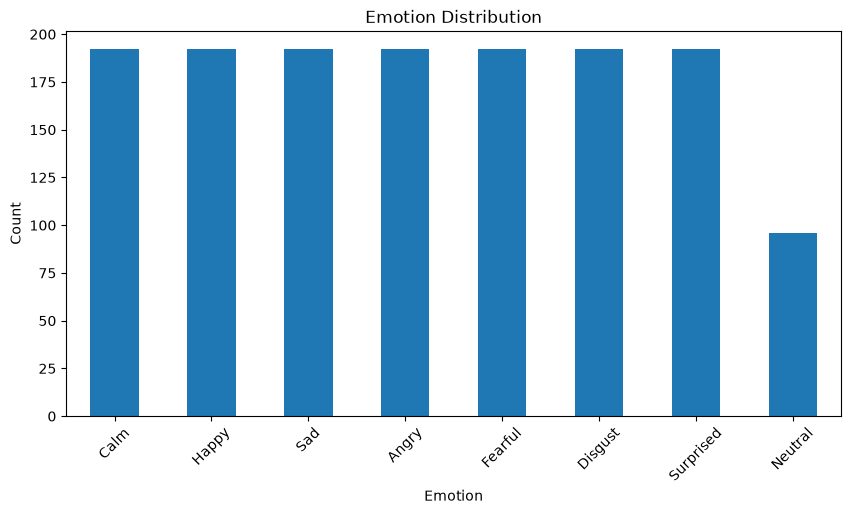

In [39]:
emotion_counts = metadata["emotion"].value_counts()

plt.figure(figsize=(10,5))

emotion_counts.plot(kind="bar")

plt.title("Emotion Distribution")

plt.xlabel("Emotion")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

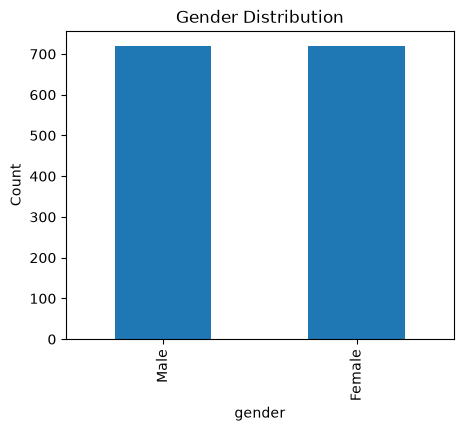

In [40]:
gender_counts = metadata["gender"].value_counts()

plt.figure(figsize=(5,4))

gender_counts.plot(kind="bar")

plt.title("Gender Distribution")

plt.ylabel("Count")

plt.show()

In [41]:
save_path = PROJECT_ROOT / "data" / "metadata" / "metadata.csv"

metadata.to_csv(save_path, index=False)

print("Saved Successfully!")

Saved Successfully!


In [42]:
pd.read_csv(save_path).head()

,filename,filepath,emotion_code,emotion,intensity,statement,repetition,actor,gender
0,03-01-01-01-01-01-01.wav,..\data\raw\RAVDESS\Actor_01\03-01-01-01-01-01...,1,Neutral,Normal,Kids are talking by the door,1,1,Male
1,03-01-01-01-01-02-01.wav,..\data\raw\RAVDESS\Actor_01\03-01-01-01-01-02...,1,Neutral,Normal,Kids are talking by the door,2,1,Male
2,03-01-01-01-02-01-01.wav,..\data\raw\RAVDESS\Actor_01\03-01-01-01-02-01...,1,Neutral,Normal,Dogs are sitting by the door,1,1,Male
3,03-01-01-01-02-02-01.wav,..\data\raw\RAVDESS\Actor_01\03-01-01-01-02-02...,1,Neutral,Normal,Dogs are sitting by the door,2,1,Male
4,03-01-02-01-01-01-01.wav,..\data\raw\RAVDESS\Actor_01\03-01-02-01-01-01...,2,Calm,Normal,Kids are talking by the door,1,1,Male


# Observations

- Dataset contains 1440 speech samples.
- There are 24 professional actors.
- 12 male and 12 female.
- Dataset contains 8 emotions.
- Classes are balanced.
- Every filename contains complete metadata.
- Metadata has been successfully generated and saved.